<a href="https://colab.research.google.com/github/kimve1969/PINN/blob/main/pinn-2d-heat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Решение 2D нестационарного уравнения теплопроводности

Уравнение:
$$ \frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad (x,y,t) \in [0,1]^3
$$
Численная схема — явная FTCS (Forward-Time, Central-Space):
$$
u_{i,j}^{n+1} = u_{i,j}^n + r_x(u_{i+1,j}^n - 2u_{i,j}^n + u_{i-1,j}^n) + r_y(u_{i,j+1}^n - 2u_{i,j}^n + u_{i,j-1}^n)
$$
где
$$ r_x = \alpha\Delta t/\Delta x^2, $$
$$ r_y = \alpha\Delta t/\Delta y^2. $$
Условие устойчивости: $$ r_x + r_y \le 1/2 $$ — код автоматически подбирает dt.

Параметры, которые можно менять

Параметр Смысл
alpha температуропроводность
Nx, Ny размер сетки (точность)
u = np.exp(...) начальное условие
apply_bc граничные условия (Дирихле / Нейман / смешанные)

Альтернативные варианты

· Неявная схема (Crank–Nicolson) — устойчива при больших dt, но требует решения СЛАУ (scipy.sparse.linalg.spsolve) на каждом шаге.
· Готовые функции: scipy.integrate.solve_ivp для метода прямых (MOL).
· Граничные условия Неймана (теплоизоляция): u[0,:] = u[1,:] вместо u[0,:] = 0.

dt = 9.000000e-03, Nt = 112
rx = 0.2250, ry = 0.2250, r = 0.9000 (должно быть <= 1)


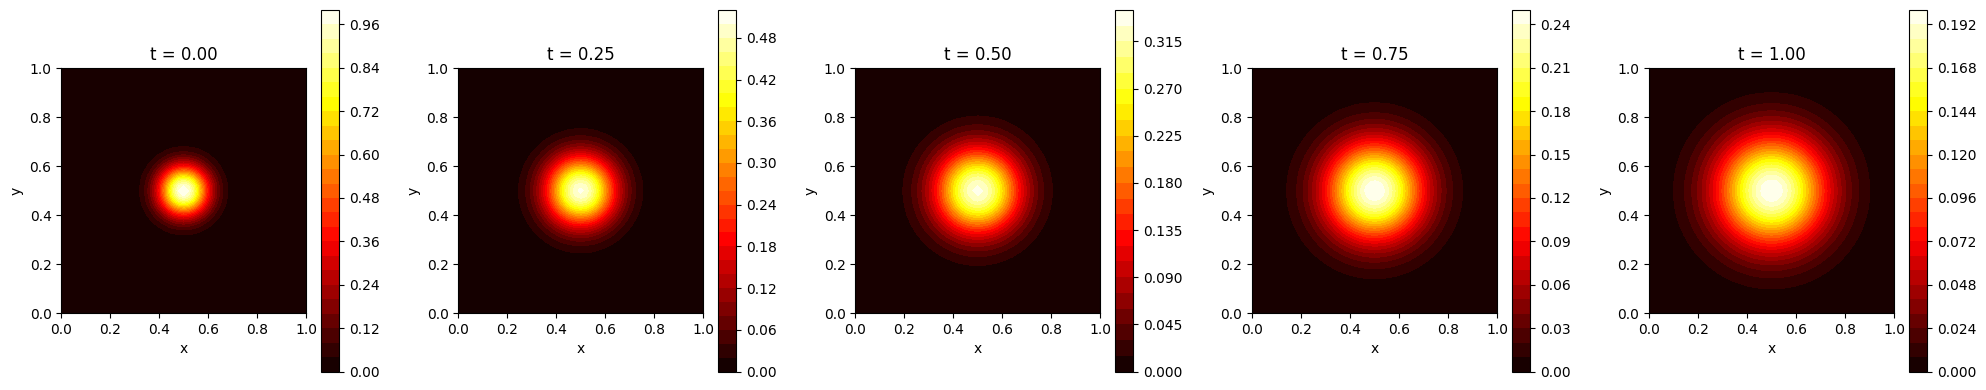

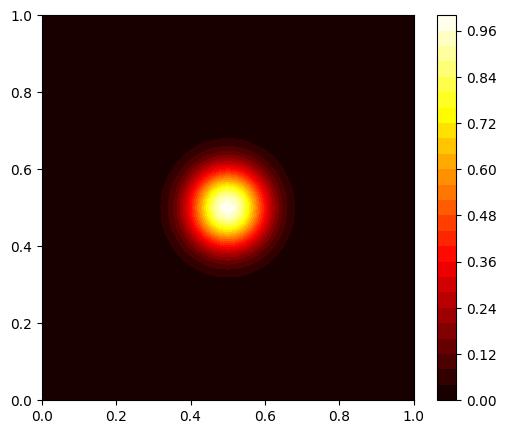

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============ Параметры задачи ============
Lx, Ly = 1.0, 1.0          # размеры области по x и y
T_final = 1.0              # конечное время
alpha = 0.01               # коэффициент температуропроводности
Nx, Ny = 51, 51            # число узлов сетки
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

# Условие устойчивости: dt <= 1 / (2*alpha*(1/dx^2 + 1/dy^2))
dt_max = 1.0 / (2 * alpha * (1/dx**2 + 1/dy**2))
dt = 0.9 * dt_max
Nt = int(T_final / dt) + 1
print(f"dt = {dt:.6e}, Nt = {Nt}")

# ============ Сетка ============
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# ============ Начальное условие ============
u = np.zeros((Nx, Ny))
# Например: гауссов "горячий" источник в центре
u = np.exp(-100 * ((X - 0.5)**2 + (Y - 0.5)**2))

# ============ Граничные условия (нулевые - холодные стенки) ============
def apply_bc(u):
    u[0, :]  = 0.0   # x = 0
    u[-1, :] = 0.0   # x = 1
    u[:, 0]  = 0.0   # y = 0
    u[:, -1] = 0.0   # y = 1
    return u

u = apply_bc(u)
u0 = u.copy()

# ============ Явная схема (метод FTCS) ============
rx = alpha * dt / dx**2
ry = alpha * dt / dy**2
print(f"rx = {rx:.4f}, ry = {ry:.4f}, r = {2*(rx+ry):.4f} (должно быть <= 1)")

# Массивы для сохранения решения в контрольные моменты времени
save_times = [0.0, 0.25, 0.5, 0.75, 1.0]
solutions = []
save_indices = [int(t / dt) for t in save_times]

u_new = u.copy()
for n in range(Nt):
    if n in save_indices:
        solutions.append(u.copy())

    # Конечные разности (явная схема)
    u_new[1:-1, 1:-1] = (
        u[1:-1, 1:-1]
        + rx * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])
        + ry * (u[1:-1, 2:]  - 2*u[1:-1, 1:-1] + u[1:-1, :-2])
    )
    u_new = apply_bc(u_new)
    u, u_new = u_new, u

# ============ Визуализация ============
fig, axes = plt.subplots(1, len(solutions), figsize=(4*len(solutions), 4))
if len(solutions) == 1:
    axes = [axes]

for ax, t, sol in zip(axes, save_times, solutions):
    im = ax.contourf(X, Y, sol, levels=30, cmap='hot')
    ax.set_title(f't = {t:.2f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('heat_2d_solution.png', dpi=120)
plt.show()

# ============ Анимация ============
fig2, ax2 = plt.subplots(figsize=(6, 5))
c = ax2.contourf(X, Y, u0, levels=30, cmap='hot', vmin=0, vmax=u0.max())
plt.colorbar(c, ax=ax2)

# Пересчитываем решение для анимации
u = u0.copy()
u_new = u.copy()
frames = []

anim_step = max(1, Nt // 100)
for n in range(Nt):
    if n % anim_step == 0:
        frames.append(u.copy())
    u_new[1:-1, 1:-1] = (
        u[1:-1, 1:-1]
        + rx * (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1])
        + ry * (u[1:-1, 2:]  - 2*u[1:-1, 1:-1] + u[1:-1, :-2])
    )
    u_new = apply_bc(u_new)
    u, u_new = u_new, u

def update(frame):
    ax2.clear()
    ax2.contourf(X, Y, frame, levels=30, cmap='hot', vmin=0, vmax=u0.max())
    ax2.set_title(f'2D уравнение теплопроводности')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_aspect('equal')

ani = FuncAnimation(fig2, update, frames=frames, interval=80)
plt.show()